# narrative review n-grams

In [9]:
import json
import pandas as pd


# import all papers excluded by langdetect
removed = []
with open("../../data/processed/preprocess_log.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        removed.append(json.loads(line))


In [13]:
removed[-1].keys()

dict_keys(['timestamp_utc', 'raw_dir', 'processed_dir', 'filtered_out_dir', 'title_patterns', 'abstract_phrases', 'total_read', 'total_kept', 'dropped_duplicates', 'dropped_non_english', 'dropped_no_doi', 'dropped_ngram', 'dropped_by_rule', 'batches_written'])

In [16]:
removed[-1]["dropped_by_rule"]

{'title:NarrRev': 38643,
 'title:NarrSum': 58,
 'title:NarrSyn': 1371,
 'title:NarrMeta': 4,
 'title:NarrOverview': 184,
 'abstract:narrative review': 29298,
 'abstract:narrative synthesis': 9692,
 'abstract:narrative literature review': 2766,
 'abstract:narrative summary': 1078,
 'abstract:synthesized narratively': 808,
 'abstract:narratively synthesized': 496,
 'abstract:synthesised narratively': 475,
 'abstract:narratively synthesised': 363,
 'abstract:narrative overview': 286}

In [24]:
import pandas as pd

dropped = removed[-1]["dropped_by_rule"]

df = (
    pd.Series(dropped, name="nr_removed")
      .rename_axis("rule")
      .reset_index()
)

df[["text_type", "term_pattern"]] = df["rule"].str.split(":", n=1, expand=True)

df = (
    df[["term_pattern", "text_type", "nr_removed"]]
    .sort_values("nr_removed", ascending=False)
    .reset_index(drop=True)
)

df

,term_pattern,text_type,nr_removed
0,NarrRev,title,38643
1,narrative review,abstract,29298
2,narrative synthesis,abstract,9692
3,narrative literature review,abstract,2766
4,NarrSyn,title,1371
5,narrative summary,abstract,1078
6,synthesized narratively,abstract,808
7,narratively synthesized,abstract,496
8,synthesised narratively,abstract,475
9,narratively synthesised,abstract,363


In [25]:
# ---------------------------------------------------------
# Create LaTeX table
# ---------------------------------------------------------

rows = []

for _, row in df.iterrows():
    rows.append(
        f"{row['term_pattern']} & "
        f"{row['text_type'].capitalize()} & "
        f"{row['nr_removed']:,} \\\\"
    )

latex_table = r"""\begin{table}[ht]
%\centering
\caption{Records removed by exclusion rule}
\label{tab:removed_by_rule}
\begin{tabularx}{\textwidth}{Xlr}
\toprule
Term / pattern & Text type & Removed\\
\midrule
""" + "\n".join(rows) + r"""
\bottomrule
\end{tabularx}
\end{table}
"""

print(latex_table)


\begin{table}[ht]
%\centering
\caption{Records removed by exclusion rule}
\label{tab:removed_by_rule}
\begin{tabularx}{\textwidth}{Xlr}
\toprule
Term / pattern & Text type & Removed\\
\midrule
NarrRev & Title & 38,643 \\
narrative review & Abstract & 29,298 \\
narrative synthesis & Abstract & 9,692 \\
narrative literature review & Abstract & 2,766 \\
NarrSyn & Title & 1,371 \\
narrative summary & Abstract & 1,078 \\
synthesized narratively & Abstract & 808 \\
narratively synthesized & Abstract & 496 \\
synthesised narratively & Abstract & 475 \\
narratively synthesised & Abstract & 363 \\
narrative overview & Abstract & 286 \\
NarrOverview & Title & 184 \\
NarrSum & Title & 58 \\
NarrMeta & Title & 4 \\
\bottomrule
\end{tabularx}
\end{table}



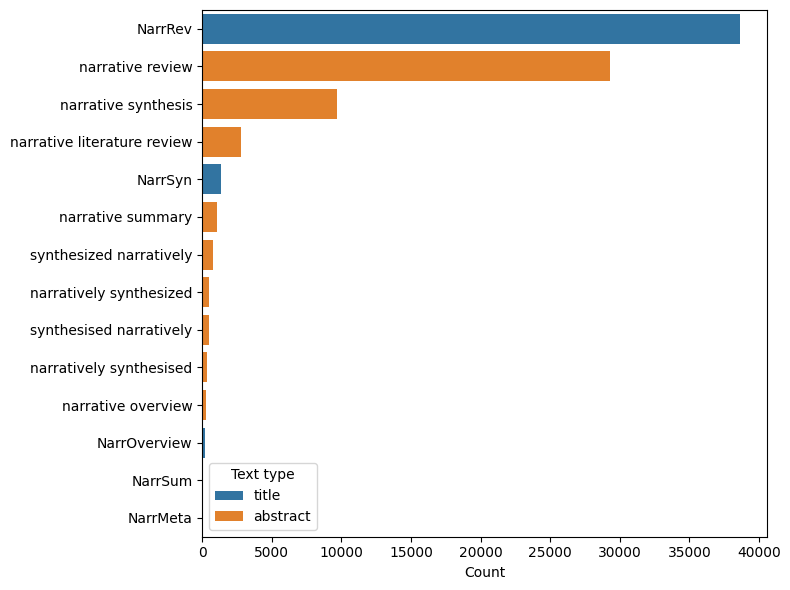

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# sort so bars appear in descending order top-to-bottom
df_sorted = df.sort_values("nr_removed", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_sorted,
    x="nr_removed",
    y="term_pattern",
    hue="text_type",
    dodge=False
)
plt.xlabel("Count")
plt.ylabel("")
#plt.title("Number of records removed by term pattern")
plt.legend(title="Text type")
plt.tight_layout()
plt.show()